# Voiceprint Verification Model

This notebook builds and evaluates machine learning models for voiceprint verification using extracted audio features.

## Models to Evaluate:
- Random Forest
- Logistic Regression
- XGBoost

## Evaluation Metrics:
- Accuracy
- F1-Score
- Loss (Cross-entropy for classification)


In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, log_loss
from xgboost import XGBClassifier
import joblib

# Set up matplotlib for inline display
%matplotlib inline
plt.style.use('default')
sns.set_palette("husl")


## Step 1: Load and Explore the Data

Load the extracted features from the CSV file.


In [5]:
# Load the features CSV
features_path = Path("features/audio_features.csv")
df = pd.read_csv(features_path)

print("=" * 60)
print("Dataset Overview")
print("=" * 60)
print(f"Total samples: {len(df)}")
print(f"Total features: {len(df.columns) - 3}")
print(f"\nColumns: {len(df.columns)}")
print(f"\nMembers: {df['member'].unique()}")
print(f"\nAugmentations: {df['augmentation'].unique()}")

# Display first few rows
print(f"\n{'='*60}")
print("First 5 rows:")
print(f"{'='*60}")
display(df.head())

# Check for missing values
print(f"\n{'='*60}")
print("Missing values:")
print(f"{'='*60}")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values!")

# Display data distribution
print(f"\n{'='*60}")
print("Sample distribution by member:")
print(f"{'='*60}")
print(df['member'].value_counts())


Dataset Overview
Total samples: 24
Total features: 122

Columns: 125

Members: ['damour' 'denise' 'kelia' 'stecie']

Augmentations: ['original' 'pitch_shift_up' 'pitch_shift_down']

First 5 rows:


,member,audio_file,augmentation,mfcc_mean_0,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,mfcc_mean_4,mfcc_mean_5,mfcc_mean_6,...,chroma_max_4,chroma_max_5,chroma_max_6,chroma_max_7,chroma_max_8,chroma_max_9,chroma_max_10,chroma_max_11,duration,sample_rate
0,damour,audio_da1,original,-472.790314,117.520683,35.111450,13.942045,4.573158,1.808872,-5.694975,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.432018,22050.0
1,damour,audio_da1,pitch_shift_up,-500.355927,119.928719,30.294065,9.936377,3.109880,-1.011334,-7.735586,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.432018,22050.0
2,damour,audio_da1,pitch_shift_down,-514.564636,121.792175,34.431622,20.549639,4.346860,8.419610,-5.534846,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.432018,22050.0
3,damour,audio_da2,original,-452.491150,124.398758,19.745743,8.620334,-6.135910,4.615840,-5.763838,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.528027,22050.0
4,damour,audio_da2,pitch_shift_up,-478.200653,125.970718,15.637498,2.667925,-5.790166,4.340361,-8.106912,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.528027,22050.0



Missing values:
No missing values!

Sample distribution by member:
member
damour    6
denise    6
kelia     6
stecie    6
Name: count, dtype: int64


## Step 2: Prepare the Data

Separate features and labels, and prepare for model training.


In [6]:
# Separate features and target
# Exclude non-feature columns
exclude_cols = ['member', 'audio_file', 'augmentation']
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols]
y = df['member']

print(f"Feature shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nNumber of features: {len(feature_cols)}")
print(f"Number of classes: {len(y.unique())}")

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\nLabel mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label}: {i}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\n{'='*60}")
print("Train/Test Split:")
print(f"{'='*60}")
print(f"Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing samples: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeatures scaled using StandardScaler")


Feature shape: (24, 122)
Target shape: (24,)

Number of features: 122
Number of classes: 4

Label mapping:
  damour: 0
  denise: 1
  kelia: 2
  stecie: 3

Train/Test Split:
Training samples: 19 (79.2%)
Testing samples: 5 (20.8%)

Features scaled using StandardScaler


## Step 3: Train and Evaluate Models

Train multiple models and evaluate their performance.


In [7]:
# Initialize models
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    )
}

# Store results
results = []

print("=" * 60)
print("Training Models")
print("=" * 60)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    if name == 'Logistic Regression':
        # Logistic Regression needs scaled features
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)
    else:
        # Tree-based models can work with original features
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    loss = log_loss(y_test, y_pred_proba)
    
    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1-Score': f1,
        'Loss': loss
    })
    
    print(f"  ✓ Training complete")
    print(f"    Accuracy: {accuracy:.4f}")
    print(f"    F1-Score: {f1:.4f}")
    print(f"    Loss: {loss:.4f}")

# Create results DataFrame
results_df = pd.DataFrame(results)
print(f"\n{'='*60}")
print("Model Comparison")
print(f"{'='*60}")
display(results_df)


Training Models

Training Random Forest...
  ✓ Training complete
    Accuracy: 1.0000
    F1-Score: 1.0000
    Loss: 0.5840

Training Logistic Regression...
  ✓ Training complete
    Accuracy: 1.0000
    F1-Score: 1.0000
    Loss: 0.1174

Training XGBoost...
  ✓ Training complete
    Accuracy: 1.0000
    F1-Score: 1.0000
    Loss: 0.1661

Model Comparison


,Model,Accuracy,F1-Score,Loss
0,Random Forest,1.0,1.0,0.583959
1,Logistic Regression,1.0,1.0,0.117372
2,XGBoost,1.0,1.0,0.166148


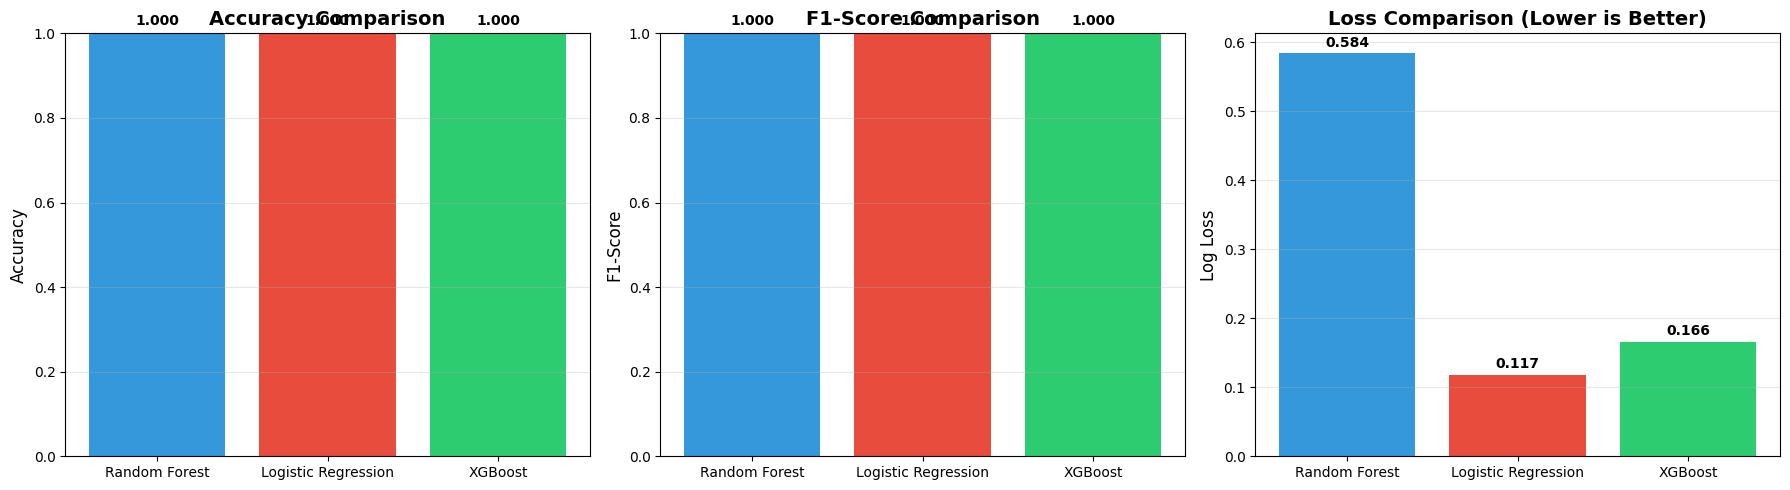

Comparison plot saved to reports/model_comparison.png


In [8]:
# Create comparison plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy comparison
axes[0].bar(results_df['Model'], results_df['Accuracy'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['Accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# F1-Score comparison
axes[1].bar(results_df['Model'], results_df['F1-Score'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1].set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('F1-Score', fontsize=12)
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['F1-Score']):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Loss comparison (lower is better)
axes[2].bar(results_df['Model'], results_df['Loss'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[2].set_title('Loss Comparison (Lower is Better)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Log Loss', fontsize=12)
axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['Loss']):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('reports/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Comparison plot saved to reports/model_comparison.png")


## Step 5: Detailed Evaluation of Best Model

Get detailed classification reports and confusion matrices for each model.


In [9]:
# Find the best model based on F1-Score
best_model_name = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
best_model = models[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"  Accuracy: {results_df.loc[results_df['F1-Score'].idxmax(), 'Accuracy']:.4f}")
print(f"  F1-Score: {results_df.loc[results_df['F1-Score'].idxmax(), 'F1-Score']:.4f}")
print(f"  Loss: {results_df.loc[results_df['F1-Score'].idxmax(), 'Loss']:.4f}")

# Retrain best model for detailed evaluation
if best_model_name == 'Logistic Regression':
    best_model.fit(X_train_scaled, y_train)
    y_pred_best = best_model.predict(X_test_scaled)
    y_pred_proba_best = best_model.predict_proba(X_test_scaled)
else:
    best_model.fit(X_train, y_train)
    y_pred_best = best_model.predict(X_test)
    y_pred_proba_best = best_model.predict_proba(X_test)

# Classification Report
print(f"\n{'='*60}")
print(f"Classification Report - {best_model_name}")
print(f"{'='*60}")
print(classification_report(y_test, y_pred_best, target_names=label_encoder.classes_))


Best Model: Random Forest
  Accuracy: 1.0000
  F1-Score: 1.0000
  Loss: 0.5840

Classification Report - Random Forest
              precision    recall  f1-score   support

      damour       1.00      1.00      1.00         1
      denise       1.00      1.00      1.00         1
       kelia       1.00      1.00      1.00         2
      stecie       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



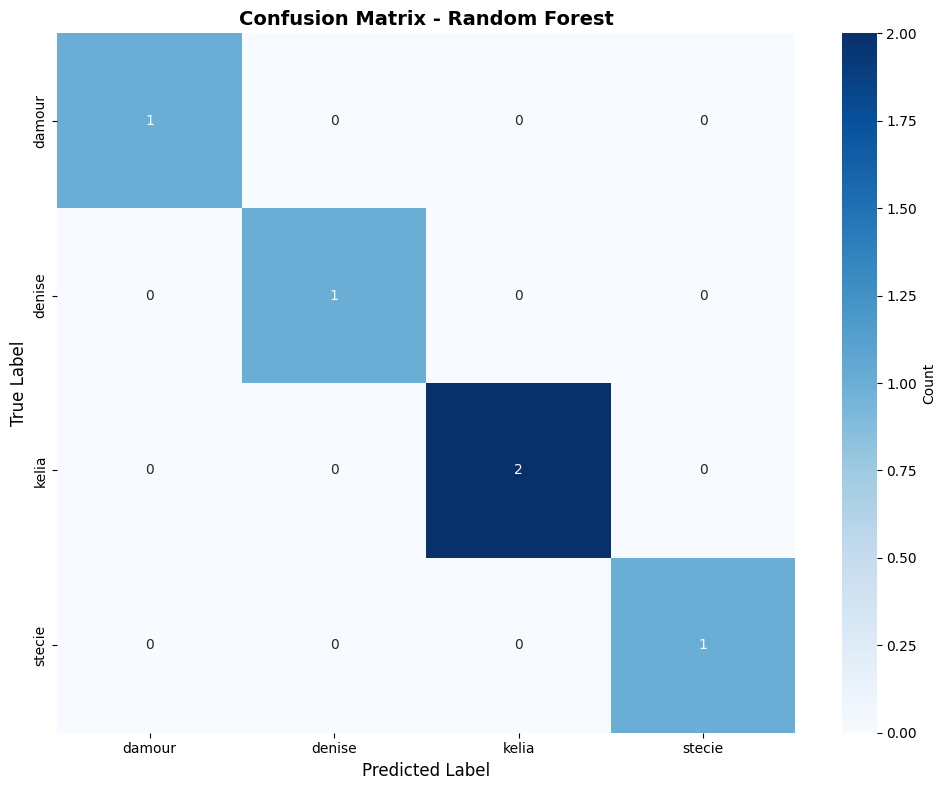

Confusion matrix saved to reports/confusion_matrix.png


In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('reports/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrix saved to reports/confusion_matrix.png")


## Step 6: Feature Importance Analysis

Analyze which features are most important for the best model.


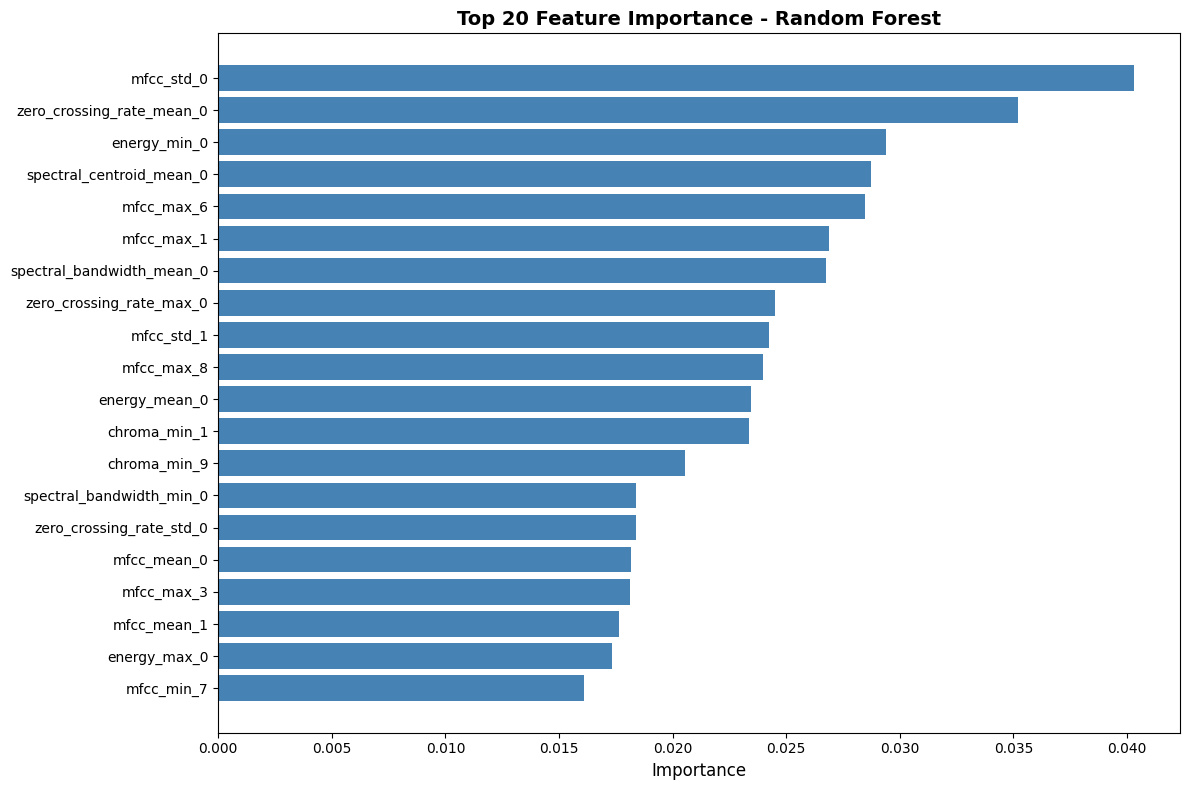

Feature importance plot saved to reports/feature_importance.png

Top 10 Most Important Features:


,feature,importance
13,mfcc_std_0,0.040315
60,zero_crossing_rate_mean_0,0.035208
58,energy_min_0,0.029377
64,spectral_centroid_mean_0,0.028712
45,mfcc_max_6,0.028482
40,mfcc_max_1,0.026872
68,spectral_bandwidth_mean_0,0.026729
63,zero_crossing_rate_max_0,0.024493
14,mfcc_std_1,0.024258
47,mfcc_max_8,0.023996


In [11]:
# Get feature importance for tree-based models
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Plot top 20 features
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(20)
    plt.barh(range(len(top_features)), top_features['importance'], color='steelblue')
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance', fontsize=12)
    plt.title(f'Top 20 Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('reports/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Feature importance plot saved to reports/feature_importance.png")
    print(f"\nTop 10 Most Important Features:")
    print(f"{'='*60}")
    display(feature_importance.head(10))
elif hasattr(best_model, 'coef_'):
    # For Logistic Regression, use absolute coefficients
    coef_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': np.abs(best_model.coef_[0])  # Average across classes
    }).sort_values('importance', ascending=False)
    
    # Plot top 20 features
    plt.figure(figsize=(12, 8))
    top_features = coef_importance.head(20)
    plt.barh(range(len(top_features)), top_features['importance'], color='steelblue')
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Absolute Coefficient', fontsize=12)
    plt.title(f'Top 20 Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('reports/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Feature importance plot saved to reports/feature_importance.png")
    print(f"\nTop 10 Most Important Features:")
    print(f"{'='*60}")
    display(coef_importance.head(10))
else:
    print("Feature importance not available for this model type.")


In [12]:
# Create models directory
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Save the best model
model_path = models_dir / "voiceprint_verification_model.pkl"
joblib.dump(best_model, model_path)
print(f"✓ Model saved to: {model_path}")

# Save the scaler
scaler_path = models_dir / "voiceprint_scaler.pkl"
joblib.dump(scaler, scaler_path)
print(f"✓ Scaler saved to: {scaler_path}")

# Save the label encoder
encoder_path = models_dir / "voiceprint_label_encoder.pkl"
joblib.dump(label_encoder, encoder_path)
print(f"✓ Label encoder saved to: {encoder_path}")

# Save model metadata
metadata = {
    'model_name': best_model_name,
    'accuracy': float(results_df.loc[results_df['F1-Score'].idxmax(), 'Accuracy']),
    'f1_score': float(results_df.loc[results_df['F1-Score'].idxmax(), 'F1-Score']),
    'loss': float(results_df.loc[results_df['F1-Score'].idxmax(), 'Loss']),
    'feature_columns': feature_cols,
    'n_classes': len(label_encoder.classes_),
    'class_names': label_encoder.classes_.tolist()
}

import json
metadata_path = models_dir / "voiceprint_model_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Metadata saved to: {metadata_path}")

print(f"\n{'='*60}")
print("Model Training Complete!")
print(f"{'='*60}")
print(f"Best Model: {best_model_name}")
print(f"All files saved to: {models_dir}/")


✓ Model saved to: models\voiceprint_verification_model.pkl
✓ Scaler saved to: models\voiceprint_scaler.pkl
✓ Label encoder saved to: models\voiceprint_label_encoder.pkl
✓ Metadata saved to: models\voiceprint_model_metadata.json

Model Training Complete!
Best Model: Random Forest
All files saved to: models/
